In [1]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt


In [2]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [7]:

from sklearn.model_selection import train_test_split

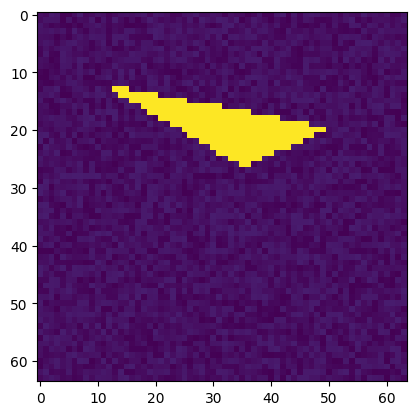

In [13]:

shapes = ['circle', 'square', 'triangle']
data = []
labels = []

def create_shape(shape):
    img = np.zeros((64, 64), dtype=np.uint8)
    center_x = random.randint(20, 44)
    center_y = random.randint(20, 44)
    size = random.randint(10, 20)

    if shape == 'circle':
        cv2.circle(img, (center_x, center_y), size, 255, -1)

    elif shape == 'square':
        half = size
        top_left = (center_x - half, center_y - half)
        bottom_right = (center_x + half, center_y + half)
        cv2.rectangle(img, top_left, bottom_right, 255, -1)

    elif shape == 'triangle':
        pts = np.array([[random.randint(10, 54), random.randint(10, 54)] for _ in range(3)], np.int32)
        pts = pts.reshape((-1, 1, 2))  # Required shape for fillPoly
        cv2.fillPoly(img, [pts], 255)

    # Optional: Add slight noise
    noise = np.random.randint(0, 20, (64, 64), dtype=np.uint8)
    img = cv2.add(img, noise)

    return img

temp_shape = create_shape("triangle")
plt.imshow(temp_shape)
# Create dataset
for _ in range(100000):
    shape = random.choice(shapes)
    img = create_shape(shape)
    data.append(img.flatten() / 255.0)
    labels.append(shapes.index(shape))

In [15]:
# X = np.array(data)
# y = to_categorical(labels)
X = np.array(data[:10000]) 
y = to_categorical(labels[:10000])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Sequential([
    Dense(128, activation='relu', input_shape=(64*64,)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6498 - loss: 0.7299 - val_accuracy: 0.8545 - val_loss: 0.3161
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9166 - loss: 0.2470 - val_accuracy: 0.9585 - val_loss: 0.1402
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9670 - loss: 0.1012 - val_accuracy: 0.9655 - val_loss: 0.1013
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9856 - loss: 0.0529 - val_accuracy: 0.9695 - val_loss: 0.0931
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9927 - loss: 0.0296 - val_accuracy: 0.9835 - val_loss: 0.0456
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9992 - loss: 0.0098 - val_accuracy: 0.9825 - val_loss: 0.0537
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9984 - loss: 0.0096 - val_accuracy: 0.9895 - val_loss: 0.0340
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9865 - loss: 0.0418
Test Accuracy: 98.90%


In [17]:
def test(img):
    # Predict class using the trained model
    img_flat = img.flatten().reshape(1, -1)  # Shape: (1, 4096)
    prediction = model.predict(img_flat)
    predicted_label = np.argmax(prediction)

    # Label mapping
    shapes = ['circle', 'square', 'triangle']
    print("Predicted Shape:", shapes[predicted_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Shape: triangle


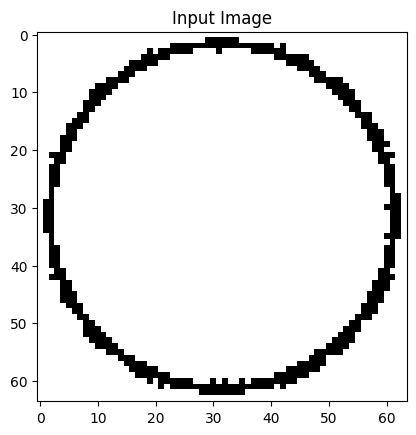

In [18]:
circle = cv2.imread('circle.png', cv2.IMREAD_GRAYSCALE)
circle = cv2.resize(circle, (64, 64))
circle //= 255

test(circle)
# Optional: Visualize
plt.imshow(circle, cmap='gray')
plt.title("Input Image")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Shape: triangle


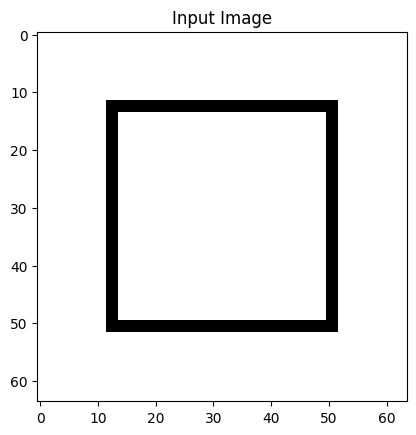

In [19]:
square = cv2.imread('square.png', cv2.IMREAD_GRAYSCALE)
square = cv2.resize(square, (64, 64))
square //= 255

test(square)
# Optional: Visualize
plt.imshow(square, cmap='gray')
plt.title("Input Image")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Shape: triangle


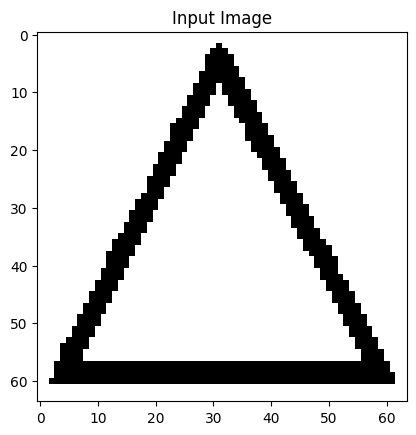

In [20]:
triangle = cv2.imread('triangle.webp', cv2.IMREAD_GRAYSCALE)
triangle = cv2.resize(triangle, (64, 64))
triangle //= 255

test(triangle)
# Optional: Visualize
plt.imshow(triangle, cmap='gray')
plt.title("Input Image")
plt.show()